<a href="https://colab.research.google.com/github/2003Himansh/Data-Analysis-Portfolio/blob/main/Sports_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install libraries for data analysis and visualization
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better plots
sns.set_style("whitegrid")

In [ ]:
# Load matches dataset
matches = pd.read_csv("/content/matches.csv")

# Load deliveries dataset
deliveries = pd.read_csv("/content/deliveries.csv")

# Display first rows
matches.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [ ]:
# Dataset shape
print("Matches dataset shape:", matches.shape)
print("Deliveries dataset shape:", deliveries.shape)

# Column names
print(matches.columns)

# Dataset info
print(matches.info())

# Check missing values
print(matches.isnull().sum())

Matches dataset shape: (756, 18)
Deliveries dataset shape: (51631, 21)
Index(['id', 'Season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   Season           756 non-null    object
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           7

In [ ]:
# Fill missing values in winner column
matches['winner'].fillna("No Result", inplace=True)

# Replace missing city values
matches['city'].fillna("Unknown", inplace=True)

/tmp/ipykernel_485/2339418311.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['winner'].fillna("No Result", inplace=True)
/tmp/ipykernel_485/2339418311.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

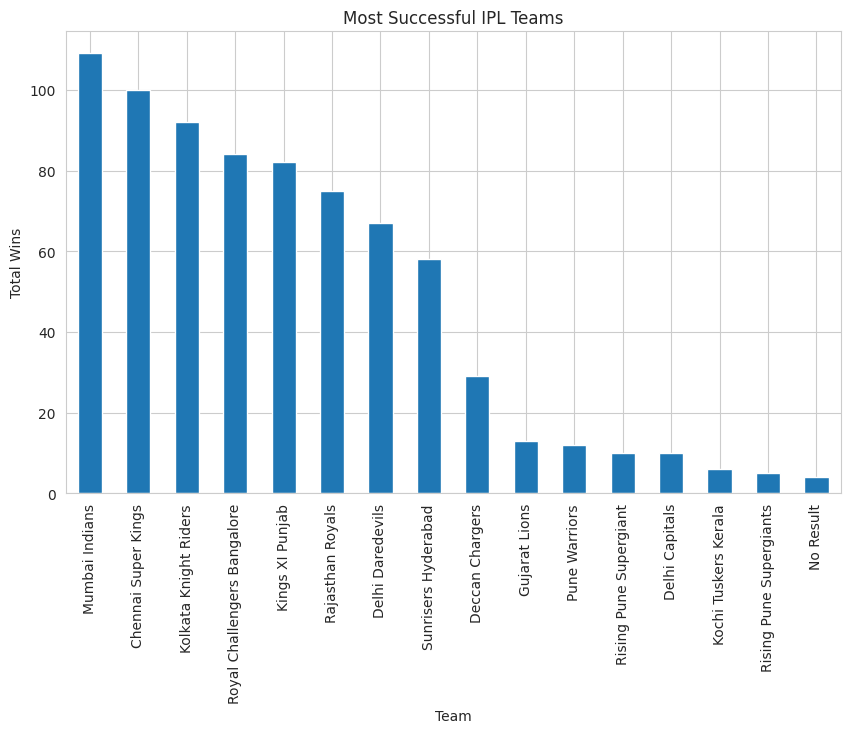

In [ ]:
# Count wins by team
team_wins = matches['winner'].value_counts()

plt.figure(figsize=(10,6))

team_wins.plot(kind='bar')

plt.title("Most Successful IPL Teams")
plt.xlabel("Team")
plt.ylabel("Total Wins")

plt.show()

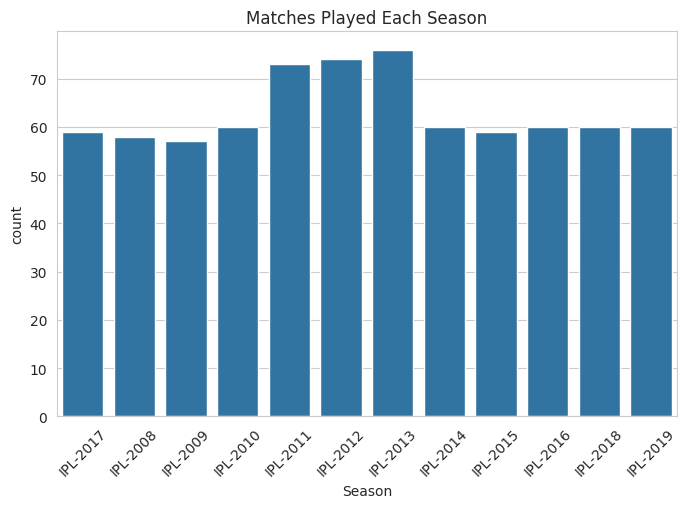

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Season', data=matches)

plt.xticks(rotation=45)

plt.title("Matches Played Each Season")

plt.show()

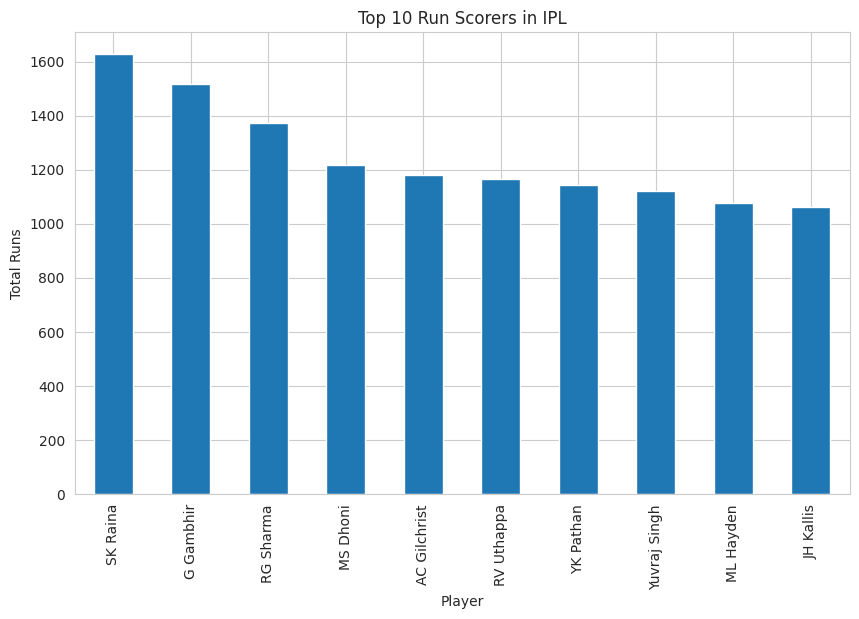

In [ ]:
# Calculate total runs scored by batsmen
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_batsmen.plot(kind='bar')

plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Player")
plt.ylabel("Total Runs")

plt.show()

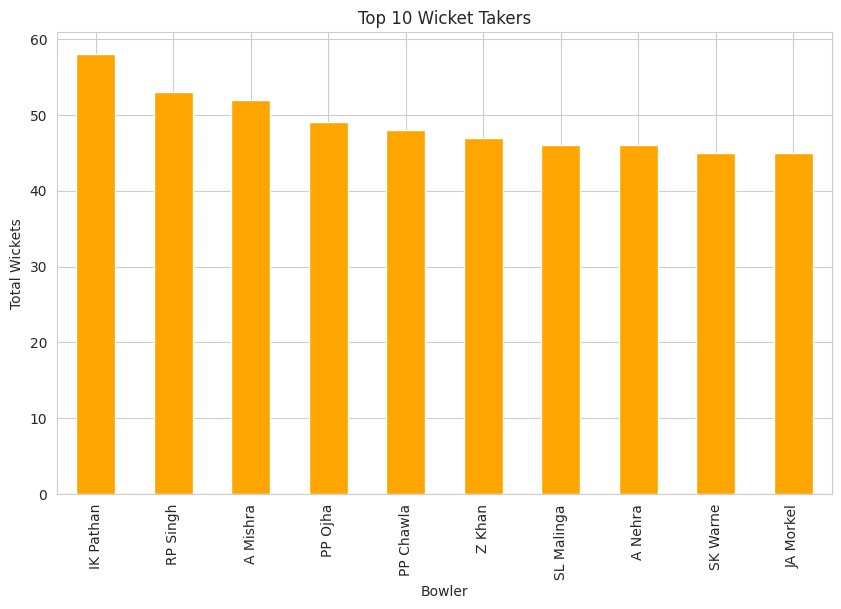

In [ ]:
# Filter wicket data
wickets = deliveries[deliveries['dismissal_kind'].notnull()]

# Count wickets by bowler
top_bowlers = wickets['bowler'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_bowlers.plot(kind='bar', color='orange')

plt.title("Top 10 Wicket Takers")
plt.xlabel("Bowler")
plt.ylabel("Total Wickets")

plt.show()

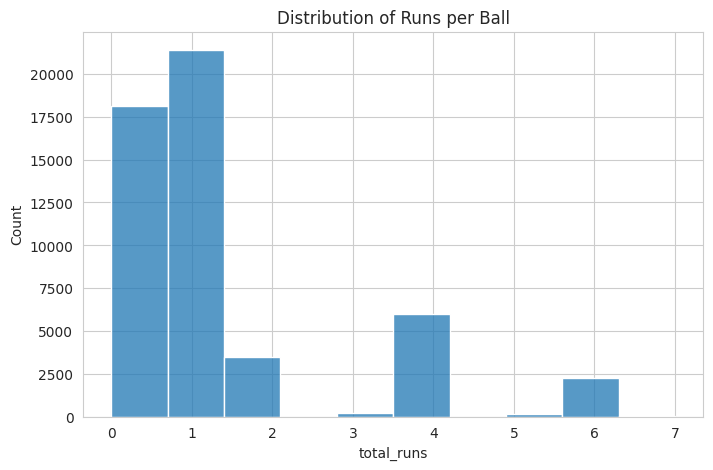

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(deliveries['total_runs'], bins=10)

plt.title("Distribution of Runs per Ball")

plt.show()

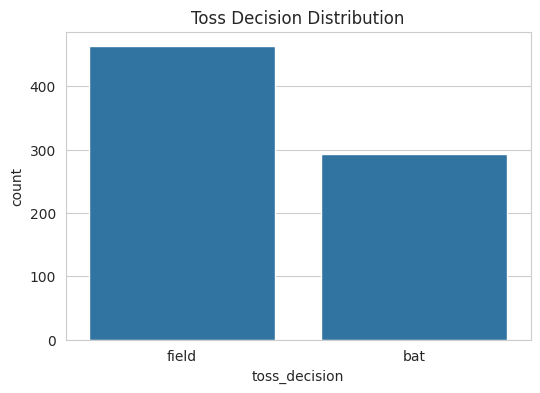

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='toss_decision', data=matches)

plt.title("Toss Decision Distribution")

plt.show()

In [ ]:
# Check how many times toss winner also won match
toss_match_win = matches[matches['toss_winner'] == matches['winner']]

percentage = (len(toss_match_win) / len(matches)) * 100

print("Toss winner also won match:", percentage, "%")

Toss winner also won match: 51.98412698412699 %


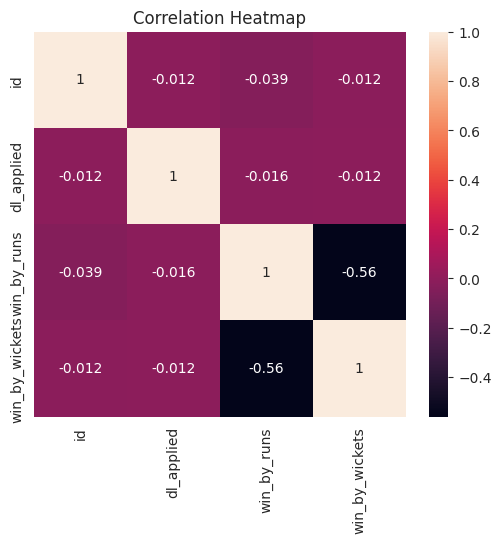

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(matches.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Select important features
data = matches[['team1','team2','toss_winner','toss_decision','winner']]

# Remove missing values
data = data.dropna()

In [ ]:
# Convert text data into numeric using encoding
data_encoded = pd.get_dummies(data, columns=['team1','team2','toss_winner','toss_decision'])

In [ ]:
#define feature and target
X = data_encoded.drop('winner', axis=1)
y = data_encoded['winner']

In [ ]:
#split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#train model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
#prediction
predictions = model.predict(X_test)

In [ ]:
#model accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.5657894736842105
